<a href="https://colab.research.google.com/github/UAMCAntwerpen/2040FBDBIC/blob/main/08_Bond_stretching_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## C-C bond stretch with parameters from AMBER FF (ff14SB)
$E = k * (b-b_{ref})^2$

$Boltzman = exp(-(E_1-E_0)/RT)$

In [41]:
# b_ref = 1.522 Angstrom
# k = 317 kcal / (mol * Aˆ2)
b_ref = 1.522
k = 317.0

# b_min = lower limit of sampling space
# b_max = upper limit of sampling space
b_min = -0.01
b_max = +0.01

In [37]:
# Function to calculate energy
def E(b, b_ref, k):
  return k * (b - b_ref) * (b - b_ref)

In [38]:
# Function to calculate relative Boltzman factor
import math

def BF(e0, e1, t):
  R = 0.001987      # Gas constant in kcal / (K * mol) units
  return math.exp(-(e1-e0) / R * t)

In [47]:
# Metropolis Monte Carlo method
import random
bond_list = []
T = 300
b0 = b_ref
e0 = E(b0, b_ref, k)

for i in range(1000000):
  delta_b = random.uniform(b_min, b_max)
  b1 = b0 + delta_b
  e1 = E(b1, b_ref, k)
  
  if e1 <= e0:
    # Accept b1
    bond_list.append(b1)
    b0 = b1
    e0 = e1
  else:
    a = random.random()
    if BF(e0, e1, T) > a:
      # Accept b1
      bond_list.append(b1)
      b0 = b1
      e0 = e1
    else:
      bond_list.append(b0)

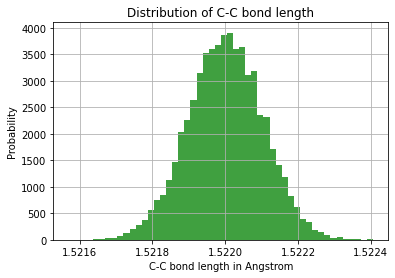

In [49]:
import numpy as np
import matplotlib.pyplot as plt

n, bins, patches = plt.hist(bond_list, 50, density=True, facecolor='g', alpha=0.75)

plt.xlabel('C-C bond length in Angstrom')
plt.ylabel('Probability')
plt.title('Distribution of C-C bond length')
plt.grid(True)
plt.show()